# Pipeline 4 – Clustering

## 2. Affinity Propagation clustering Experiment

本 notebook 完整覆盖：

- **2.1 Brief Introduction of AP**：AP 核心思想、常用参数、与 KMeans 的区别。
- **2.2 AP for clustering with visualization**：Iris 数据集，t-SNE scatter plot，逐迭代展示并标记中心点 / exemplar。
- **2.3 Explore AP with different parameters**：探索 `preference p` 和 `max_iter / iters`，使用 DBI，并与 KMeans 对比。



## 🌱 课前准备

建议在 Jupyter Notebook / VSCode Notebook / Google Colab 中运行。

本实验依赖：

- `numpy`：数值计算
- `pandas`：表格展示
- `matplotlib`：画图
- `scikit-learn`：Iris 数据、标准化、t-SNE、AP、KMeans、DBI

### 零基础学生需要先知道

1. **样本**：一行数据，例如一朵鸢尾花。
2. **特征**：描述样本的属性，例如花瓣长度、花瓣宽度。
3. **聚类**：没有答案标签时，让算法自己把相似样本分组。

In [2]:
# =========================
# 0. 检查运行环境
# =========================
import os
# 限制底层数值库线程数，避免部分电脑 / 在线环境中 KMeans 或 t-SNE 出现运行很慢的问题
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.cluster import AffinityPropagation, KMeans

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Python version      :", sys.version.split()[0])
print("Platform            :", platform.platform())
print("scikit-learn version:", sklearn.__version__)

Python version      : 3.9.23
Platform            : macOS-15.6-arm64-arm-64bit
scikit-learn version: 1.6.1


# 📖 2.1 Affinity Propagation 简介

## 1. 用生活例子理解 AP

假设一个班级要做小组活动，但老师不提前规定分几组。

每个学生都可以问：

> “我适不适合当组长？”  
> “别人适不适合当我的组长？”

经过多轮讨论后，班级会自动选出若干个比较有代表性的学生作为“组长”，其他学生加入和自己最相似的组长所在的小组。

这就是 Affinity Propagation 的直觉：

- 每个数据点都可能成为中心点。
- 算法不需要提前指定 `K`。
- 数据点之间会通过“消息传递”不断更新谁更适合作为中心。
- 最终被选中的中心点称为 **exemplar**。

---

## 2. AP 和 KMeans 的区别

| 对比点 | KMeans | Affinity Propagation |
|---|---|---|
| 是否需要提前指定簇数 | 需要指定 `K` | 不需要指定 `K` |
| 中心点是什么 | 均值点，可能不是原始样本 | exemplar，必须是原始样本 |
| 主要输入 | 特征矩阵 + K | 相似度矩阵 + preference |
| 计算成本 | 通常较低 | 相似度矩阵是 n × n，数据大时更慢 |
| 可解释性 | 中心是平均值 | 中心是真实样本，更容易展示 |


KMeans 是“指定 K 个虚拟中心，然后按距离分组”；AP 是“让样本互相传递信息，自动选出真实样本作为中心”。

最重要的区别是：

KMeans：需要提前给 K，中心是平均点  
AP：不需要提前给 K，中心是真实数据点

## 3. AP 的核心：相似度矩阵 Similarity Matrix

AP 不是直接问“点之间距离多远”，而是问：

> 两个样本有多相似？

本实验使用负的平方欧氏距离作为相似度：

\[
s(i,k) = -\|x_i - x_k\|^2
\]

距离越近，平方距离越小，加负号之后数值越大，所以表示越相似。

---

## 4. AP 的两个消息

AP 的迭代过程主要更新两个矩阵：

### Responsibility：责任度

\[
r(i,k)
\]

表示：

> 从样本 \(i\) 的角度看，样本 \(k\) 有多适合当 \(i\) 的中心？

### Availability：可用度

\[
a(i,k)
\]

表示：

> 从其他样本的角度看，样本 \(k\) 有多适合被 \(i\) 选择为中心？

可以简单理解为：

- `r`：我觉得你适不适合当中心。
- `a`：大家觉得你有没有资格当中心。
- 最后看 `r(k,k) + a(k,k)`，如果这个值足够强，样本 `k` 就可能成为中心点。

## 5. AP 的重要参数

### `preference` / `p`

这是 AP 中最重要的参数之一。

它控制每个样本“想当中心”的倾向，通常放在相似度矩阵的对角线上：

\[
s(k,k)=p
\]

直觉上：

- `p` 越大：更多点愿意当中心，簇数量通常变多。
- `p` 越小：更少点愿意当中心，簇数量通常变少。

### `damping`

阻尼系数，用来让迭代更稳定。

AP 反复更新消息，如果更新太激进，可能会震荡。`damping` 的作用类似：

> 这一次不要完全相信新消息，而是保留一部分旧消息。

常见取值：`0.5 ~ 0.95`

### `max_iter` / `iters`

最大迭代次数。  
迭代次数太少可能还没收敛，太多会增加计算时间。

### `convergence_iter`

如果连续若干轮中心点没有变化，就认为算法收敛。

# 🔍 一个小玩具例子：AP 自动选择代表点

先不用 Iris，我们用简单二维数据直观看 AP 的效果。

下面的图中：

- 小点是普通样本。
- 星号是 AP 自动找到的代表点，也就是 exemplar。
- AP 没有提前告诉算法应该分几类。

AP 自动找到的簇数量: 3
中心点 / exemplar 的样本编号: [17 72 73]


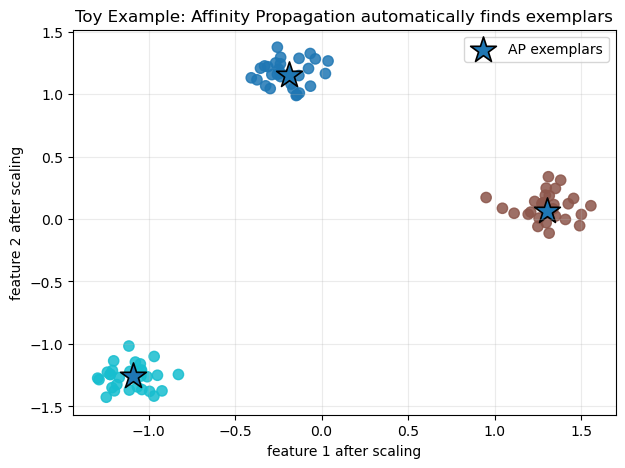

In [3]:
# =========================
# 1. 用玩具数据直观感受 AP
# =========================

X_toy, y_toy_true = make_blobs(
    n_samples=90,
    centers=3,
    cluster_std=0.65,
    random_state=42
)

scaler_toy = StandardScaler()
X_toy_scaled = scaler_toy.fit_transform(X_toy)

ap_toy = AffinityPropagation(
    damping=0.75,
    preference=None,
    max_iter=200,
    random_state=42
)
toy_labels = ap_toy.fit_predict(X_toy_scaled)
toy_centers = ap_toy.cluster_centers_indices_

print("AP 自动找到的簇数量:", len(np.unique(toy_labels)))
print("中心点 / exemplar 的样本编号:", toy_centers)

plt.figure(figsize=(7, 5))
plt.scatter(X_toy_scaled[:, 0], X_toy_scaled[:, 1], c=toy_labels, cmap="tab10", s=55, alpha=0.85)
plt.scatter(
    X_toy_scaled[toy_centers, 0],
    X_toy_scaled[toy_centers, 1],
    marker="*",
    s=380,
    edgecolor="black",
    linewidth=1.2,
    label="AP exemplars"
)
plt.title("Toy Example: Affinity Propagation automatically finds exemplars")
plt.xlabel("feature 1 after scaling")
plt.ylabel("feature 2 after scaling")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

AP 不需要提前告诉它要分成几类，它会通过样本之间的相似度自动选择中心点。  
为什么这三个点会被选为中心  因为 AP 会计算样本之间的相似度。    
如果一个点满足下面两个条件，它就更可能成为 exemplar：

1. 它和同簇内很多点都比较相似
2. 它的位置比较居中，能代表这一团数据

# 🌸 读取 Iris 数据集

Iris 是机器学习入门中非常经典的数据集。

每个样本是一朵鸢尾花，有 4 个特征：

1. `sepal length (cm)`：萼片长度
2. `sepal width (cm)`：萼片宽度
3. `petal length (cm)`：花瓣长度
4. `petal width (cm)`：花瓣宽度

真实类别有 3 种：

- Setosa
- Versicolor
- Virginica

注意：聚类是无监督学习，训练时不能把真实类别告诉算法。真实类别只用于最后帮助理解结果。

In [4]:
# =========================
# 2. 读取 Iris 数据集
# =========================
iris = load_iris(as_frame=True)

X_df = iris.data.copy()
y_true = iris.target.copy()
target_names = iris.target_names
y_name = y_true.map(lambda i: target_names[i])

print("Feature matrix shape:", X_df.shape)
print("Target shape        :", y_true.shape)
print("Feature names:")
print(list(X_df.columns))

print("\nFirst 5 rows:")
display(X_df.head())

print("\nClass distribution:")
display(y_name.value_counts())

Feature matrix shape: (150, 4)
Target shape        : (150,)
Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Class distribution:


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 为什么聚类前要标准化？

Iris 的 4 个特征单位都是 cm，但不同特征的数值范围仍然不同。

如果不标准化，距离计算可能被数值范围大的特征主导。

标准化之后，每个特征大致变成：

- 均值为 0
- 标准差为 1

这对于基于距离 / 相似度的聚类算法非常重要。

In [5]:
# =========================
# 3. 数据标准化
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns)

print("Before scaling:")
display(X_df.describe().loc[["mean", "std", "min", "max"]])

print("\nAfter scaling:")
display(X_scaled_df.describe().loc[["mean", "std", "min", "max"]])

Before scaling:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000



After scaling:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


# 👀 先看看 Iris 的二维散点图

虽然 Iris 有 4 个特征，但人眼更容易看二维图。

这里先选两个非常常用的特征：

- `petal length (cm)`
- `petal width (cm)`

这两个特征通常对区分鸢尾花比较明显。

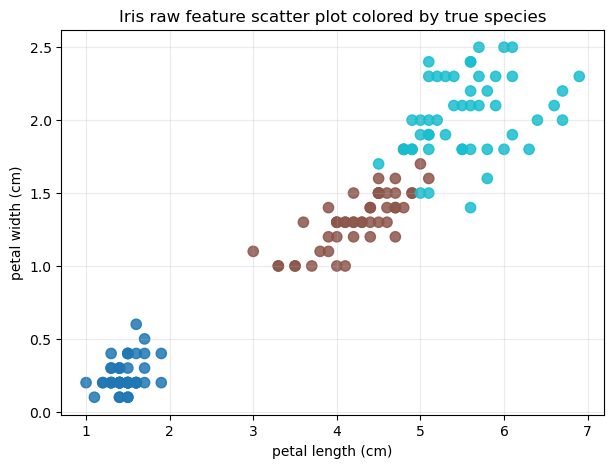

说明：这里颜色使用真实类别，只是为了直观看到数据结构。
真正做聚类时，AP 并不知道这些真实类别。


In [6]:
# =========================
# 4. 使用两个特征做直观散点图
# =========================
feature_x = "petal length (cm)"
feature_y = "petal width (cm)"

plt.figure(figsize=(7, 5))
plt.scatter(
    X_df[feature_x],
    X_df[feature_y],
    c=y_true,
    cmap="tab10",
    s=55,
    alpha=0.85
)
plt.title("Iris raw feature scatter plot colored by true species")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.grid(alpha=0.25)
plt.show()

print("说明：这里颜色使用真实类别，只是为了直观看到数据结构。")
print("真正做聚类时，AP 并不知道这些真实类别。")

# 🧭 使用 t-SNE 把 4 维数据压到 2 维

实验要求中提到：

> scatter plot by t-SNE each iter, mark the center

所以我们先把 Iris 的 4 个标准化特征用 t-SNE 降到二维。

## t-SNE 是什么？

t-SNE 是一种常见的非线性降维方法，常用于把高维数据画成二维图。

注意：

- t-SNE 主要用于可视化。
- t-SNE 图上的距离不能完全当作原始空间中的真实距离。
- 聚类算法仍然在标准化后的 4 维数据上运行，不是在 t-SNE 的 2 维坐标上运行。

,TSNE-1,TSNE-2,true_label,species
0,-18.310379,-3.730899,0,setosa
1,-14.492649,-3.411088,0,setosa
2,-15.736403,-2.709708,0,setosa
3,-15.008589,-2.458446,0,setosa
4,-18.926222,-3.310136,0,setosa


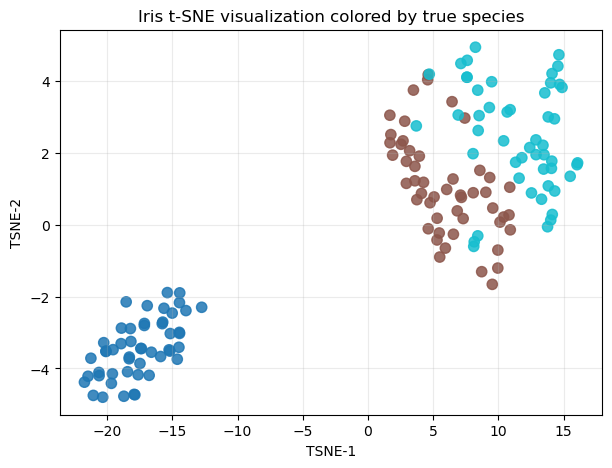

In [7]:
# =========================
# 5. t-SNE 降维
# =========================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    method="exact",   # 教学数据量很小，用 exact 更稳定；大数据时可考虑默认的 barnes_hut
    max_iter=500,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE-1", "TSNE-2"])
tsne_df["true_label"] = y_true
tsne_df["species"] = y_name.values

display(tsne_df.head())

plt.figure(figsize=(7, 5))
plt.scatter(
    tsne_df["TSNE-1"],
    tsne_df["TSNE-2"],
    c=y_true,
    cmap="tab10",
    s=55,
    alpha=0.85
)
plt.title("Iris t-SNE visualization colored by true species")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.grid(alpha=0.25)
plt.show()

# ⚙️ 2.2 AP for clustering with visualization


`sklearn.cluster.AffinityPropagation` 可以直接得到最终聚类结果，但它不方便拿到“每一次迭代中的中间中心点”。

为了教学展示：

- 我们写一个简化版 AP 迭代函数。
- 每隔几轮保存一次当前 exemplar。
- 用 t-SNE 图展示中心点如何逐步出现和稳定。


In [20]:
# =========================
# 6. 教学版 Affinity Propagation 迭代函数
# =========================

def assign_labels_from_exemplars(S, exemplars):
    """
    根据已经选出的 exemplars 给每个样本分配簇标签。

    S: 相似度矩阵，S[i, k] 表示样本 i 和样本 k 的相似度
    exemplars: 当前被选为中心的样本编号
    """
    n = S.shape[0]

    # 如果暂时还没有任何中心点，就把所有点先放到同一个临时簇里
    if len(exemplars) == 0:
        return np.zeros(n, dtype=int)

    # 对每个样本 i，找它和哪个 exemplar 最相似
    labels = np.argmax(S[:, exemplars], axis=1)
    return labels


def run_ap_for_teaching(
    X,
    preference=None,
    damping=0.75,
    max_iter=80,
    snapshot_iters=(1, 2, 5, 10, 20, 40, 60, 80)
):
    """
    教学版 AP 算法：
    - 展示 AP 如何通过迭代逐渐选出中心点 exemplar
    - 保存若干关键迭代轮次，方便画图
    """
    n = X.shape[0]

    # 1. 计算相似度矩阵：负的平方欧氏距离
    S = -pairwise_distances(X, metric="sqeuclidean")

    # 2. 设置 preference，也就是对角线上的“自我成为中心”的倾向
    if preference is None:
        # 常用做法：使用相似度的中位数作为默认 preference
        preference = np.median(S[~np.eye(n, dtype=bool)])

    np.fill_diagonal(S, preference)

    # 3. 初始化两个消息矩阵
    R = np.zeros((n, n))  # responsibility
    A = np.zeros((n, n))  # availability

    history = []

    for it in range(1, max_iter + 1):
        # -------------------------
        # Step 1: 更新 Responsibility
        # r(i,k) = s(i,k) - max_{k' != k} { a(i,k') + s(i,k') }
        # -------------------------
        AS = A + S

        max1_idx = np.argmax(AS, axis=1)
        max1 = AS[np.arange(n), max1_idx]

        # 计算每行第二大值，用于“排除当前 k 后的最大值”
        AS_second = AS.copy()
        AS_second[np.arange(n), max1_idx] = -np.inf
        max2 = np.max(AS_second, axis=1)

        R_new = S - max1[:, None]
        R_new[np.arange(n), max1_idx] = S[np.arange(n), max1_idx] - max2

        # 阻尼更新
        R = damping * R + (1 - damping) * R_new

        # -------------------------
        # Step 2: 更新 Availability
        # -------------------------
        Rp = np.maximum(R, 0)
        Rp[np.diag_indices(n)] = R[np.diag_indices(n)]
        col_sum = np.sum(Rp, axis=0)

        A_new = np.minimum(0, col_sum[None, :] - np.maximum(R, 0))
        A_new[np.diag_indices(n)] = col_sum - Rp[np.diag_indices(n)]

        A = damping * A + (1 - damping) * A_new

        # -------------------------
        # Step 3: 判断当前 exemplar
        # 如果 a(k,k) + r(k,k) > 0，说明 k 可能成为中心
        # -------------------------
        exemplar_scores = np.diag(A + R)
        exemplars = np.where(exemplar_scores > 0)[0]
        labels = assign_labels_from_exemplars(S, exemplars)

        if it in snapshot_iters:
            history.append({
                "iteration": it,
                "labels": labels.copy(),
                "exemplars": exemplars.copy(),
                "n_clusters": len(exemplars),
                "exemplar_scores": exemplar_scores.copy()
            })

    final_scores = np.diag(A + R)
    final_exemplars = np.where(final_scores > 0)[0]
    final_labels = assign_labels_from_exemplars(S, final_exemplars)

    return {
        "S": S,
        "R": R,
        "A": A,
        "preference": preference,
        "damping": damping,
        "max_iter": max_iter,
        "history": history,
        "final_exemplars": final_exemplars,
        "final_labels": final_labels,
        "final_scores": final_scores
    }


def plot_ap_snapshots(ap_result, X_2d, title_prefix="AP iteration"):
    """
    把 AP 若干次迭代结果画在 t-SNE 二维图上。
    """
    history = ap_result["history"]

    n_plots = len(history)
    n_cols = 4
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, history):
        labels = item["labels"]
        exemplars = item["exemplars"]
        iteration = item["iteration"]
        n_clusters = item["n_clusters"]

        ax.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=labels,
            cmap="tab20",
            s=45,
            alpha=0.75
        )

        if len(exemplars) > 0:
            ax.scatter(
                X_2d[exemplars, 0],
                X_2d[exemplars, 1],
                marker="*",
                s=260,
                edgecolor="black",
                linewidth=1.1,
                label="exemplars"
            )

        ax.set_title(f"{title_prefix} {iteration}: clusters = {n_clusters}")
        ax.set_xlabel("TSNE-1")
        ax.set_ylabel("TSNE-2")
        ax.grid(alpha=0.2)

    for ax in axes[len(history):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 运行教学版 AP，并画出每个关键迭代阶段

下面使用：

- `preference = similarity median`
- `damping = 0.75`
- `max_iter = 80`

观察：

1. 早期可能没有稳定中心。
2. 迭代到一定轮次后，exemplar 会逐渐出现。
3. 最后中心点可能趋于稳定。

Preference used: -6.238383145274104
Final number of exemplars: 9
Final exemplar indices: [  3   5  17  78  80 102 110 117 126]


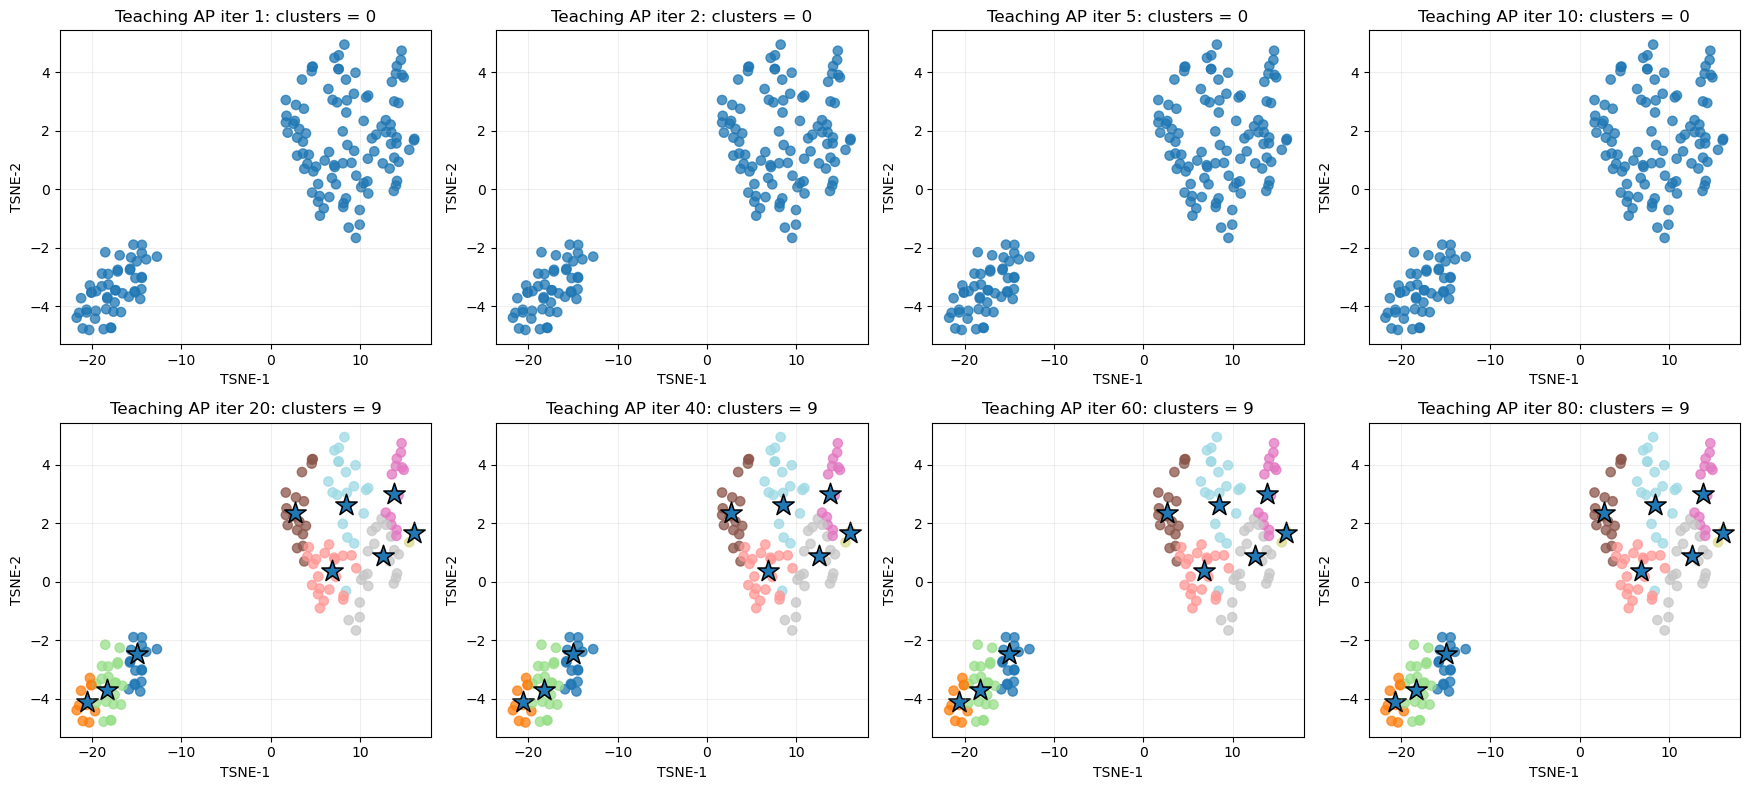

In [34]:
# =========================
# 7. 运行教学版 AP 并可视化每个关键迭代阶段
# =========================

ap_teaching = run_ap_for_teaching(
    X_scaled,
    preference=None,
    #-10 -20 -30 preference 越大 -> 越多样本愿意当中心 -> 簇数量越多  preference 越小 -> 越少样本愿意当中心 -> 簇数量越少
    damping=0.75,
    max_iter=80,
    snapshot_iters=(1, 2, 5, 10, 20, 40, 60, 80)
)

print("Preference used:", ap_teaching["preference"])
print("Final number of exemplars:", len(ap_teaching["final_exemplars"]))
print("Final exemplar indices:", ap_teaching["final_exemplars"])

plot_ap_snapshots(ap_teaching, X_tsne, title_prefix="Teaching AP iter")

第一行表示 AP 还在思考，样本之间还在互相传递信息，所以暂时没有明确中心点。  
到第 20 轮时，AP 已经选出了 9 个代表样本，这些星星就是 exemplar。  
后面的第 40、60、80 轮结果几乎不变，说明算法已经稳定。  
但 Iris 数据真实只有 3 大类，而 AP 这里分成了 9 类，说明当前 preference 让模型分得太细。  
因此 AP 的关键实验不是只跑一次，而是要调节 preference，观察簇数量和 DBI 如何变化。

## 查看 AP 最终选出来的中心点

AP 的中心点不是“均值点”，而是真实存在的数据样本。  
所以我们可以把中心点对应的原始 Iris 样本打印出来。

In [10]:
# =========================
# 8. 查看最终中心点对应的 Iris 样本
# =========================

final_exemplars = ap_teaching["final_exemplars"]
final_labels = ap_teaching["final_labels"]

center_info = X_df.iloc[final_exemplars].copy()
center_info.insert(0, "sample_index", final_exemplars)
center_info["true_species_for_reference"] = y_name.iloc[final_exemplars].values

print("AP selected exemplars:")
display(center_info)

cluster_counts = pd.Series(final_labels).value_counts().sort_index().rename("count").to_frame()
cluster_counts.index.name = "AP cluster id"

print("\nCluster size distribution:")
display(cluster_counts)

if 1 < len(np.unique(final_labels)) < len(final_labels):
    dbi_teaching = davies_bouldin_score(X_scaled, final_labels)
    print(f"DBI of teaching AP result: {dbi_teaching:.4f}")
else:
    print("DBI cannot be computed because the number of clusters is not between 2 and n-1.")

AP selected exemplars:


,sample_index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),true_species_for_reference
3,3,4.6,3.1,1.5,0.2,setosa
5,5,5.4,3.9,1.7,0.4,setosa
17,17,5.1,3.5,1.4,0.3,setosa
78,78,6.0,2.9,4.5,1.5,versicolor
80,80,5.5,2.4,3.8,1.1,versicolor
102,102,7.1,3.0,5.9,2.1,virginica
110,110,6.5,3.2,5.1,2.0,virginica
117,117,7.7,3.8,6.7,2.2,virginica
126,126,6.2,2.8,4.8,1.8,virginica



Cluster size distribution:


,count
AP cluster id,
0,16
1,11
2,23
3,23
4,18
5,15
6,22
7,2
8,20


DBI of teaching AP result: 1.1701


## AP 聚类结果和真实类别的对比

注意：

- 左图是 AP 的聚类结果。
- 右图是真实花种，只用于参考。
- 聚类算法没有使用真实类别训练。

如果 AP 的簇和真实类别不完全一致，并不代表算法一定错了。  
因为 AP 是根据特征相似度分组，而真实类别是生物学标签。

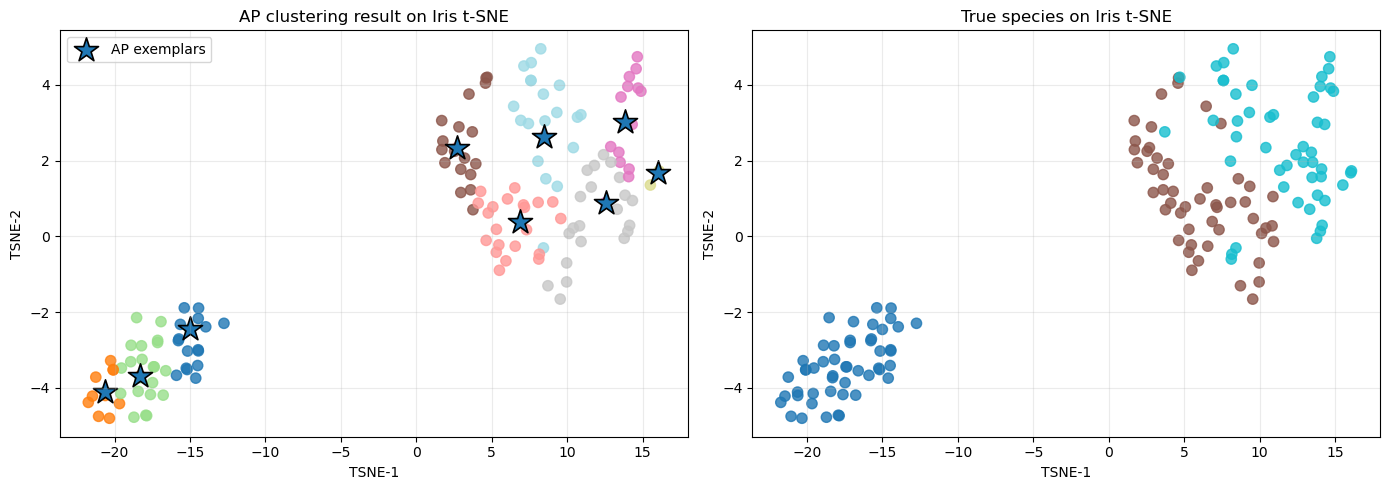

In [11]:
# =========================
# 9. AP 聚类结果 vs 真实类别
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=final_labels,
    cmap="tab20",
    s=55,
    alpha=0.8
)
axes[0].scatter(
    X_tsne[final_exemplars, 0],
    X_tsne[final_exemplars, 1],
    marker="*",
    s=330,
    edgecolor="black",
    linewidth=1.2,
    label="AP exemplars"
)
axes[0].set_title("AP clustering result on Iris t-SNE")
axes[0].set_xlabel("TSNE-1")
axes[0].set_ylabel("TSNE-2")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_true,
    cmap="tab10",
    s=55,
    alpha=0.8
)
axes[1].set_title("True species on Iris t-SNE")
axes[1].set_xlabel("TSNE-1")
axes[1].set_ylabel("TSNE-2")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 📏 2.3 Explore AP with different parameters

本节探索两个参数：

1. `preference p`
2. `max_iter / iters`

并用 **DBI（Davies-Bouldin Index）** 评价聚类结果。

## DBI 是什么？

DBI 是聚类评价指标之一，常用于无监督聚类。

直觉上：

- 簇内部越紧密越好。
- 不同簇之间越分开越好。
- DBI 越小，通常说明聚类效果越好。

但是注意：

> DBI 不是唯一标准，也不一定和真实标签完全一致。

尤其在 Iris 上，KMeans 的 DBI 最优簇数可能不是 3。  
课堂讨论：评价指标和真实任务目标并不总是一致。

,p_percentile,preference_p
0,5,-21.813047
1,15,-16.250451
2,30,-11.237631
3,50,-6.238383
4,70,-2.301889
5,90,-0.648312


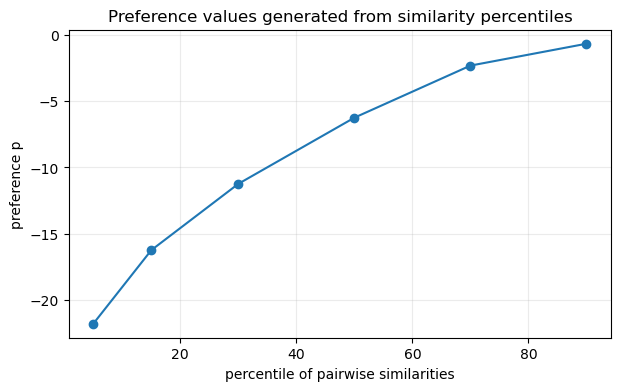

In [12]:
# =========================
# 10. 准备 preference 候选值
# =========================

S_for_pref = -pairwise_distances(X_scaled, metric="sqeuclidean")
sim_values = S_for_pref[~np.eye(S_for_pref.shape[0], dtype=bool)]

# 用不同分位数生成 preference 候选
# 越靠近 90% 的值通常越大，AP 更容易产生更多中心点
preference_percentiles = [5, 15, 30, 50, 70, 90]
preference_values = [np.percentile(sim_values, q) for q in preference_percentiles]

preference_table = pd.DataFrame({
    "p_percentile": preference_percentiles,
    "preference_p": preference_values
})

display(preference_table)

plt.figure(figsize=(7, 4))
plt.plot(preference_table["p_percentile"], preference_table["preference_p"], marker="o")
plt.title("Preference values generated from similarity percentiles")
plt.xlabel("percentile of pairwise similarities")
plt.ylabel("preference p")
plt.grid(alpha=0.25)
plt.show()

p_percentile = 5 表示： 把所有相似度从小到大排序，取排在 5% 位置的那个值。
AP 的 preference 可以从相似度矩阵的不同分位数中选取。分位数越高，preference 越接近 0，AP 越容易产生更多簇；分位数越低，preference 越负，AP 越倾向于产生更少簇。

## 参数实验设计

我们尝试：

- 多个 `p`
- 多个 `max_iter`

对于每组参数，记录：

1. AP 找到的簇数量。
2. AP 的 DBI。
3. KMeans 在相同簇数下的 DBI。

为什么 KMeans 要使用“相同簇数”？

因为 AP 会自动决定簇数，而 KMeans 必须指定 `K`。  
为了公平一点，我们让 KMeans 的 `K` 等于 AP 当前找到的簇数，然后比较 DBI。

In [13]:
# =========================
# 11. 定义 AP 和 KMeans 的参数实验函数
# =========================

def safe_dbi(X, labels):
    """
    安全计算 DBI。
    DBI 要求聚类数量必须在 2 到 n-1 之间。
    如果只有 1 个簇或每个样本都是一个簇，则不能计算。
    """
    labels = np.asarray(labels)
    n = len(labels)
    n_clusters = len(np.unique(labels))

    if n_clusters <= 1 or n_clusters >= n:
        return np.nan

    return davies_bouldin_score(X, labels)


def run_parameter_experiment(X, preference_values, preference_percentiles, iters_list, damping=0.75):
    """
    对 AP 的 preference 和 max_iter 做网格实验。
    同时用相同簇数的 KMeans 做对比。
    """
    rows = []

    for q, p in zip(preference_percentiles, preference_values):
        for max_iter in iters_list:

            with warnings.catch_warnings(record=True) as caught_warnings:
                warnings.simplefilter("always")

                ap = AffinityPropagation(
                    preference=p,
                    damping=damping,
                    max_iter=max_iter,
                    convergence_iter=15,
                    random_state=42
                )
                ap_labels = ap.fit_predict(X)

            ap_n_clusters = len(np.unique(ap_labels))
            ap_dbi = safe_dbi(X, ap_labels)

            warning_text = "; ".join([str(w.message) for w in caught_warnings])
            converged_flag = "did not converge" not in warning_text.lower()

            km_dbi = np.nan
            if 1 < ap_n_clusters < len(X):
                km = KMeans(
                    n_clusters=ap_n_clusters,
                    n_init=5,
                    algorithm="lloyd",
                    random_state=42
                )
                km_labels = km.fit_predict(X)
                km_dbi = safe_dbi(X, km_labels)

            rows.append({
                "p_percentile": q,
                "preference_p": p,
                "max_iter": max_iter,
                "AP_n_clusters": ap_n_clusters,
                "AP_DBI": ap_dbi,
                "KMeans_sameK_DBI": km_dbi,
                "AP_converged_no_warning": converged_flag
            })

    return pd.DataFrame(rows)


iters_list = [20, 50, 100, 200]

results_df = run_parameter_experiment(
    X_scaled,
    preference_values=preference_values,
    preference_percentiles=preference_percentiles,
    iters_list=iters_list,
    damping=0.75
)

display(results_df)

,p_percentile,preference_p,max_iter,AP_n_clusters,AP_DBI,KMeans_sameK_DBI,AP_converged_no_warning
0,5,-21.813047,20,5,0.964912,0.948317,False
1,5,-21.813047,50,4,0.883597,0.869779,True
2,5,-21.813047,100,4,0.883597,0.869779,True
3,5,-21.813047,200,4,0.883597,0.869779,True
4,15,-16.250451,20,5,0.964912,0.948317,False
5,15,-16.250451,50,5,0.964912,0.948317,True
6,15,-16.250451,100,5,0.964912,0.948317,True
7,15,-16.250451,200,5,0.964912,0.948317,True
8,30,-11.237631,20,6,1.154786,0.993723,False
9,30,-11.237631,50,6,1.154786,0.993723,True


## 可视化 1：不同参数下 AP 找到的簇数量

观察重点：

- `preference p` 增大时，簇数量通常会增加。
- `max_iter` 太小时，结果可能不稳定。

max_iter,20,50,100,200
p_percentile,,,,
5,5,4,4,4
15,5,5,5,5
30,6,6,6,6
50,9,9,9,9
70,16,16,16,16
90,35,31,34,33


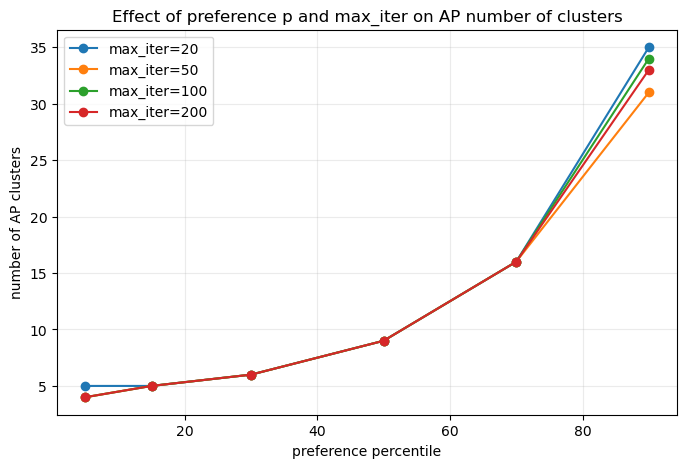

In [14]:
# =========================
# 12. preference 和 iters 对 AP 簇数量的影响
# =========================

pivot_clusters = results_df.pivot(
    index="p_percentile",
    columns="max_iter",
    values="AP_n_clusters"
)

display(pivot_clusters)

plt.figure(figsize=(8, 5))
for max_iter in iters_list:
    sub = results_df[results_df["max_iter"] == max_iter]
    plt.plot(
        sub["p_percentile"],
        sub["AP_n_clusters"],
        marker="o",
        label=f"max_iter={max_iter}"
    )

plt.title("Effect of preference p and max_iter on AP number of clusters")
plt.xlabel("preference percentile")
plt.ylabel("number of AP clusters")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

第一张图：横向看的是不同 max_iter。 
纵向看的是不同 p_percentile。 
表格里的数字表示：
AP 最终分出来的簇数量  
第二张图：说明 AP 的簇数量主要由 preference 决定；p_percentile 越高，preference 越大，最终簇数量越多，而 max_iter 只是在保证算法是否充分收敛。

## 可视化 2：AP 的 DBI 热力图

热力图可以快速看出哪些参数组合 DBI 更低。

注意：

- DBI 越低通常越好。
- 但 DBI 可能偏好某些簇数量，并不一定等于真实类别数量。

max_iter,20,50,100,200
p_percentile,,,,
5,0.964912,0.883597,0.883597,0.883597
15,0.964912,0.964912,0.964912,0.964912
30,1.154786,1.154786,1.154786,1.154786
50,0.975990,0.975990,0.975990,0.975990
70,0.856208,0.856208,0.856208,0.856208
90,0.787577,0.879455,0.806870,0.828748


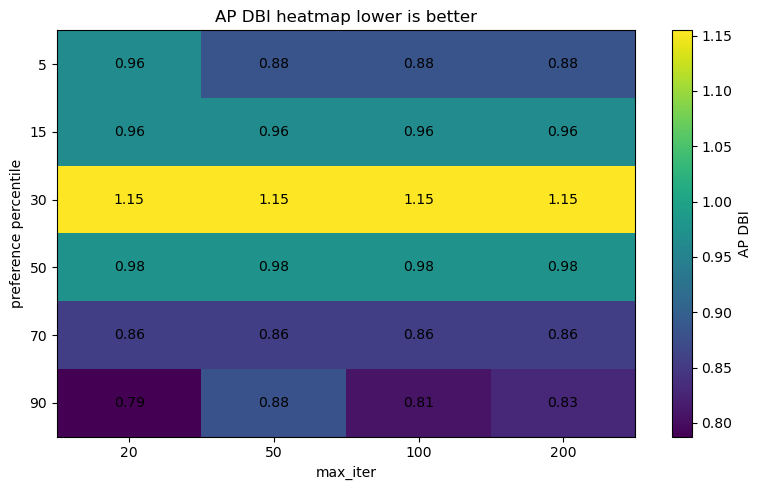

In [15]:
# =========================
# 13. AP DBI heatmap
# =========================

pivot_ap_dbi = results_df.pivot(
    index="p_percentile",
    columns="max_iter",
    values="AP_DBI"
)

display(pivot_ap_dbi)

plt.figure(figsize=(8, 5))
im = plt.imshow(pivot_ap_dbi.values, aspect="auto")

plt.xticks(range(len(pivot_ap_dbi.columns)), pivot_ap_dbi.columns)
plt.yticks(range(len(pivot_ap_dbi.index)), pivot_ap_dbi.index)

plt.xlabel("max_iter")
plt.ylabel("preference percentile")
plt.title("AP DBI heatmap lower is better")
plt.colorbar(im, label="AP DBI")

for i in range(pivot_ap_dbi.shape[0]):
    for j in range(pivot_ap_dbi.shape[1]):
        value = pivot_ap_dbi.values[i, j]
        text = "nan" if np.isnan(value) else f"{value:.2f}"
        plt.text(j, i, text, ha="center", va="center")

plt.tight_layout()
plt.show()

从 DBI 热力图可以看出，AP 的聚类效果主要受 preference p 影响，而 max_iter 的影响相对较小。  
较高的 p_percentile，如 90%，可以得到较低的 DBI，但同时会产生 30 多个簇，说明 AP 将数据划分得过细。  
较低的 p_percentile，如 5%，虽然 DBI 不是最低，但最终簇数量约为 4，更接近 Iris 数据集的真实 3 类。  
因此，在实际选择参数时，不能只根据 DBI 最小来判断，还需要结合簇数量和可视化结果共同分析。

## 可视化 3：AP 和 KMeans 在相同簇数下比较 DBI

这张图回答一个问题：

> 当 AP 自动找到某个簇数 K 后，如果让 KMeans 也用这个 K，谁的 DBI 更低？

注意：

- KMeans 是以“均值中心”为代表。
- AP 是以“真实样本 exemplar”为代表。
- 两者优化目标不同，所以 DBI 表现也可能不同。

,p_percentile,preference_p,AP_n_clusters,AP_DBI,KMeans_sameK_DBI
3,5,-21.813047,4,0.883597,0.869779
7,15,-16.250451,5,0.964912,0.948317
11,30,-11.237631,6,1.154786,0.993723
15,50,-6.238383,9,0.975990,0.903152
19,70,-2.301889,16,0.856208,0.880056
23,90,-0.648312,33,0.828748,0.817550


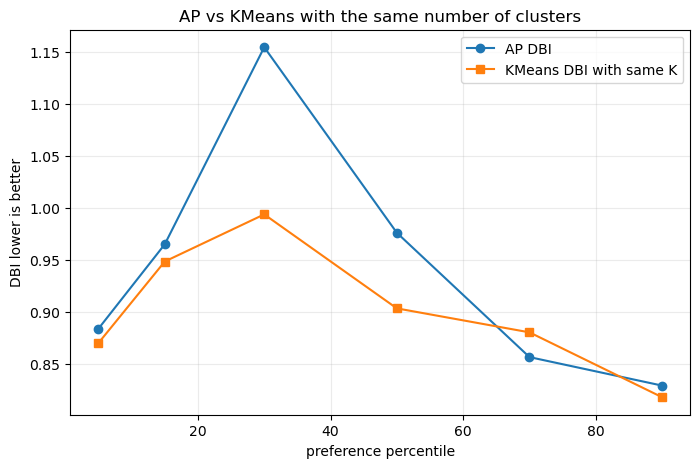

In [16]:
# =========================
# 14. AP vs KMeans same K
# =========================

compare_df = results_df[results_df["max_iter"] == 200].copy()

display(compare_df[[
    "p_percentile",
    "preference_p",
    "AP_n_clusters",
    "AP_DBI",
    "KMeans_sameK_DBI"
]])

plt.figure(figsize=(8, 5))
plt.plot(
    compare_df["p_percentile"],
    compare_df["AP_DBI"],
    marker="o",
    label="AP DBI"
)
plt.plot(
    compare_df["p_percentile"],
    compare_df["KMeans_sameK_DBI"],
    marker="s",
    label="KMeans DBI with same K"
)

plt.title("AP vs KMeans with the same number of clusters")
plt.xlabel("preference percentile")
plt.ylabel("DBI lower is better")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

从 AP 与 KMeans 的 DBI 对比结果可以看出，在相同簇数量下，KMeans 在多数情况下取得了更低的 DBI。这是因为 KMeans 直接优化簇内距离，而 DBI 也主要衡量簇内紧密程度和簇间分离程度，因此 KMeans 在该指标上具有一定优势。  
AP 的 DBI 随着 preference 的变化波动较大，说明 AP 对 preference 参数较敏感。当 p_percentile 较高时，AP 会产生大量簇，虽然 DBI 可能降低，但聚类结果过于细碎，不一定符合 Iris 数据集的真实类别结构。因此，AP 参数选择不能只看 DBI，还需要结合簇数量和可视化结果综合判断。

## KMeans 单独扫 K，作为补充基线

因为 KMeans 必须提前指定 K，所以我们也单独测试：

\[
K = 2,3,4,\ldots,10
\]

这可以帮助学生理解：

- AP 是调 `p` 间接控制簇数。
- KMeans 是直接指定 `K`。
- DBI 最低的 K 不一定等于真实类别数 3。

,K,KMeans_DBI
0,2,0.593313
1,3,0.833595
2,4,0.869779
3,5,0.948317
4,6,0.993723
5,7,0.997734
6,8,0.914982
7,9,0.903152
8,10,0.901442


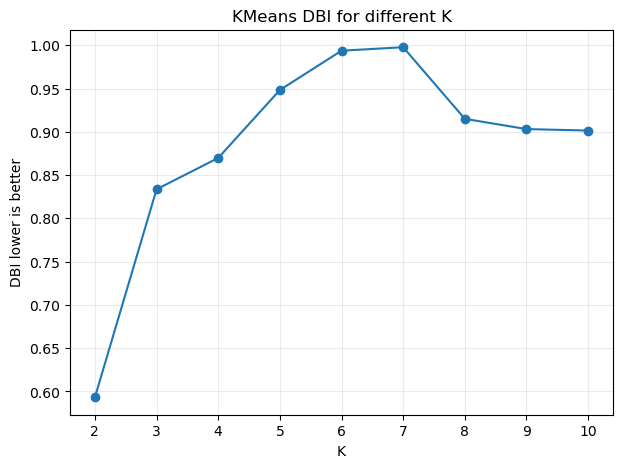

In [17]:
# =========================
# 15. KMeans 单独扫 K
# =========================

km_rows = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=5, algorithm="lloyd", random_state=42)
    km_labels = km.fit_predict(X_scaled)
    km_dbi = safe_dbi(X_scaled, km_labels)

    km_rows.append({
        "K": k,
        "KMeans_DBI": km_dbi
    })

km_sweep_df = pd.DataFrame(km_rows)

display(km_sweep_df)

plt.figure(figsize=(7, 5))
plt.plot(km_sweep_df["K"], km_sweep_df["KMeans_DBI"], marker="o")
plt.title("KMeans DBI for different K")
plt.xlabel("K")
plt.ylabel("DBI lower is better")
plt.xticks(km_sweep_df["K"])
plt.grid(alpha=0.25)
plt.show()

KMeans 在 DBI 指标下最优是 K=2，但 Iris 的真实类别是 3 类，所以 DBI 最低不一定等于真实分类最合理；DBI 只能作为聚类质量参考，不能单独决定最终 K。  
从 KMeans 的 DBI 曲线可以看出，当 K=2 时 DBI 最低，说明在 DBI 指标下，Iris 数据中最明显的划分可能是 setosa 与非 setosa 两大类。虽然 Iris 数据真实包含 3 个类别，但由于 versicolor 和 virginica 在特征空间中较为接近，K=3 的 DBI 反而高于 K=2。这说明 DBI 是无监督评价指标，只能反映簇内紧密度和簇间分离度，不能完全代表真实标签的一致性。当 K 继续增大时，DBI 整体上升，说明过大的 K 会导致过细划分，使簇之间距离变近，聚类结构变差。因此，在选择 K 时，不能只看 DBI，还需要结合真实任务、可视化结果和其他指标综合判断。

# 🧪 选择一个参数组合，画最终 AP 聚类图

下面自动选择 `AP_DBI` 最低的一组参数，然后重新训练 AP，并在 t-SNE 上画出结果和中心点。

Best AP setting according to DBI:


,p_percentile,preference_p,max_iter,AP_n_clusters,AP_DBI,KMeans_sameK_DBI,AP_converged_no_warning
20,90,-0.648312,20,35,0.787577,0.812193,False


Best AP number of clusters: 35
Best AP center indices: [ 17  19  33  34  38  41  47  56  57  58  60  63  68  80  86  94  96 101
 105 106 108 109 112 116 117 118 123 129 130 131 132 136 138 142 143]


/opt/anaconda3/envs/ann/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


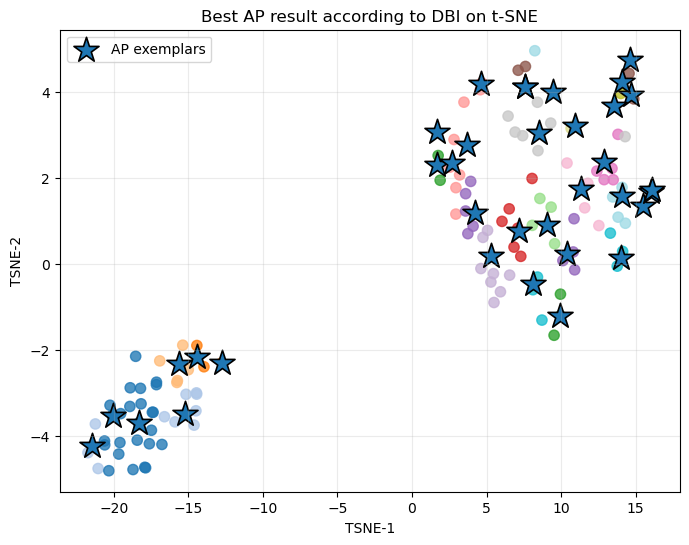

In [38]:
# =========================
# 16. 自动选择 AP_DBI 最低的参数组合，并可视化最终结果
# =========================

valid_ap = results_df.dropna(subset=["AP_DBI"]).copy()
best_ap_row = valid_ap.loc[valid_ap["AP_DBI"].idxmin()]

best_p = best_ap_row["preference_p"]
best_iter = int(best_ap_row["max_iter"])

print("Best AP setting according to DBI:")
display(best_ap_row.to_frame().T)

best_ap = AffinityPropagation(
    preference=best_p,
    damping=0.75,
    max_iter=best_iter,
    convergence_iter=15,
    random_state=42
)
best_ap_labels = best_ap.fit_predict(X_scaled)
best_ap_centers = best_ap.cluster_centers_indices_

print("Best AP number of clusters:", len(np.unique(best_ap_labels)))
print("Best AP center indices:", best_ap_centers)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=best_ap_labels,
    cmap="tab20",
    s=55,
    alpha=0.78
)

plt.scatter(
    X_tsne[best_ap_centers, 0],
    X_tsne[best_ap_centers, 1],
    marker="*",
    s=360,
    edgecolor="black",
    linewidth=1.2,
    label="AP exemplars"
)

plt.title("Best AP result according to DBI on t-SNE")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

p_percentile=90 让 preference 过大，AP 选出了过多 exemplar，最终形成 35 个簇。虽然 DBI 较低，但结果过度细分，而且算法没有收敛，因此不适合作为最终 AP 参数。更合理的做法是选择已经收敛、簇数量适中、DBI 较低的参数组合。  
按照 DBI 最小原则选出的 AP 结果。虽然该结果的 DBI 最低，但 AP 分出了 35 个簇，并且出现了未收敛警告。因此，这不是一个真正合理的聚类结果。它说明如果只用 DBI 作为选择标准，算法可能会偏向选择过多的小簇，从而获得较低的 DBI。实际调参时，需要同时考虑 DBI、簇数量、可视化效果以及算法是否收敛。

# 📌 实验结论自动总结

下面这段代码会把本次实验的关键结论打印出来，方便课堂讲解。

In [35]:
# =========================
# 17. 自动生成实验总结
# =========================

best_km_row = km_sweep_df.loc[km_sweep_df["KMeans_DBI"].idxmin()]

print("=" * 70)
print("实验总结")
print("=" * 70)

print(f"1. 在本次 AP 参数网格中，DBI 最低的 AP 参数为：")
print(f"   - preference percentile: {best_ap_row['p_percentile']}")
print(f"   - preference p         : {best_ap_row['preference_p']:.4f}")
print(f"   - max_iter             : {int(best_ap_row['max_iter'])}")
print(f"   - AP clusters          : {int(best_ap_row['AP_n_clusters'])}")
print(f"   - AP DBI               : {best_ap_row['AP_DBI']:.4f}")

print()
print(f"2. KMeans 单独扫 K 时，DBI 最低的 K 为：")
print(f"   - K                    : {int(best_km_row['K'])}")
print(f"   - KMeans DBI           : {best_km_row['KMeans_DBI']:.4f}")

print()
print("3. 重点：")
print("   - AP 不需要提前指定 K，而是通过 preference p 间接影响中心数量。")
print("   - p 越大，通常越容易产生更多 exemplar。")
print("   - damping 用于稳定迭代，防止消息来回震荡。")
print("   - DBI 越低通常代表簇内更紧密、簇间更分离，但它不一定等于真实分类准确率。")
print("   - AP 的中心点是真实样本；KMeans 的中心点是均值点，可能不是原始样本。")

实验总结
1. 在本次 AP 参数网格中，DBI 最低的 AP 参数为：
   - preference percentile: 90
   - preference p         : -0.6483
   - max_iter             : 20
   - AP clusters          : 35
   - AP DBI               : 0.7876

2. KMeans 单独扫 K 时，DBI 最低的 K 为：
   - K                    : 2
   - KMeans DBI           : 0.5933

3. 重点：
   - AP 不需要提前指定 K，而是通过 preference p 间接影响中心数量。
   - p 越大，通常越容易产生更多 exemplar。
   - damping 用于稳定迭代，防止消息来回震荡。
   - DBI 越低通常代表簇内更紧密、簇间更分离，但它不一定等于真实分类准确率。
   - AP 的中心点是真实样本；KMeans 的中心点是均值点，可能不是原始样本。


# 🧠 AP 与 KMeans 的课堂对比总结

## AP 的优点

- 不需要提前指定 K。
- 中心点是原始样本，更容易解释。
- 可以基于相似度矩阵工作，适合某些“距离不好直接定义，但相似度可以定义”的任务。

## AP 的缺点

- 需要维护 n × n 的相似度矩阵，数据大时计算和内存压力更大。
- 对 `preference` 比较敏感。
- 有时需要调 `damping` 和 `max_iter` 才能稳定收敛。

## KMeans 的优缺点

KMeans 的优点：

- 简单、快、容易理解。
- 适合球形、大小相近的簇。
- 大数据上通常更方便。

KMeans 的缺点：

- 必须提前指定 K。
- 对初始中心敏感。
- 对异常值敏感。
- 中心点是均值，不一定是真实样本。

# 📝 学生练习题

## 基础题

1. 修改 `preference_percentiles`，例如改成 `[1, 10, 25, 50, 75, 95]`，观察 AP 找到的簇数量如何变化。
2. 修改 `damping`，例如尝试 `0.55`、`0.75`、`0.90`，观察是否更容易收敛。
3. 把 `max_iter` 改小，例如 `10` 或 `20`，观察 AP 是否稳定。

## 思考题

1. 为什么 AP 不需要提前指定 K？
2. 为什么 AP 的中心点一定是原始样本，而 KMeans 的中心点不一定是原始样本？
3. 为什么 DBI 最小的结果不一定对应真实类别数？
4. 如果数据有很多噪声点，AP 和 KMeans 哪个可能更容易受影响？为什么？

## 拓展题

1. 换一个数据集，比如 `make_blobs` 或 `digits`，重新运行 AP。
2. 尝试不同的相似度定义，例如余弦相似度。
3. 对比 AP、KMeans、DBSCAN 三种聚类方法。

# ✅ 本 notebook 覆盖清单

对应任务要求：

- **2.1 Brief Introduction of AP**
  - AP 主思想
  - Similarity matrix
  - Responsibility / Availability
  - `preference p`
  - `damping`
  - `iters / max_iter`
  - AP 与 KMeans 对比

- **2.2 AP for clustering with visualization**
  - Iris 数据集
  - 标准化
  - t-SNE 可视化
  - 教学版 AP 逐迭代保存结果
  - 每个关键迭代阶段的 t-SNE scatter plot
  - 标记 center / exemplar

- **2.3 Explore AP with different parameters**
  - 不同 `p`
  - 不同 `max_iter`
  - AP 的 DBI
  - KMeans 同 K 对比 DBI
  - KMeans 独立扫 K
  - 自动总结实验结论

### 补充：PCA 与 t-SNE 的区别

| 对比项        | PCA         | t-SNE      |
| ---------- | ----------- | ---------- |
| 是否常用于可视化   | 是           | 是          |
| 降维方式       | 线性降维        | 非线性降维      |
| 主要保留什么     | 全局结构、最大方差方向 | 局部邻居关系     |
| 速度         | 快           | 较慢         |
| 稳定性        | 高           | 受随机种子影响较大  |
| 图像效果       | 比较真实、平滑     | 簇分离通常更明显   |
| 能不能直接解释坐标轴 | 相对可以        | 通常不建议解释坐标轴 |
| 适合教学聚类展示吗  | 可以          | 很适合        |
  
PCA 的核心思想是：

找到数据变化最大的方向，然后把数据投影到这些方向上。

可以理解为：

假设一团数据在空间中是斜着分布的，PCA 会找到这团数据“拉得最长”的方向。

它保留的是整体结构。

t-SNE 的核心思想是：

原来高维空间里相近的点，在二维图里也尽量放近。

它更关注局部邻居关系。

也就是说，t-SNE 更关心：

谁和谁本来就很像？
谁应该在图上靠近谁？

所以 t-SNE 画出来的图经常会让簇看起来更加分开，更适合展示聚类效果。